In [1]:
import numpy as np
import pandas as pd
import time
import os

import seaborn as sns
import matplotlib.pyplot as plt

from utils.label_query import query_labels
from utils.result_plotter import plot_ssalad_results
from utils.semi_supervised_trainer import run_experiment


In [2]:
dataset_subset = [x.replace(".npz", "") for x in os.listdir("./data/")]

In [3]:
def check_column_types(arr):
    num_columns = arr.shape[1]
    num_rows = arr.shape[0]
    numerical_index  = []
    category_index = []
    for i in range(num_columns):
        column = arr[:, i]
        unique_vals = np.unique(column)
        #percentage of unique vs all records
        pct_unique = (len(unique_vals)/num_rows)*100
        # chec if the column is one-hot encoded (binary with 2 unique values)
        # print(f"Column {i} might be one-hot encoded (unique values: {pct_unique}  {len(unique_vals)})")
        if len(unique_vals) == 2 and set(unique_vals) == {0, 1}:
            category_index.append(i)
        # chekc if the column has a small number of unique values (i.e like 1% of total records)
        # we also assume that we cannot have more than 50 unique categories in a data no matter its size
        elif pct_unique < 1 and len(unique_vals)<50:
            category_index.append(i)
        else:
            numerical_index.append(i)
    return category_index, numerical_index

In [4]:

data_info = {}
for each_data in dataset_subset:
    path = f'data/{each_data}.npz'
    try:
        data = np.load(path, allow_pickle=True)
        X, y = data['X'], data['y']

        cat_index, num_index = check_column_types(X)
        data_info[each_data] = [cat_index, num_index, X.shape[1]]
    except Exception as e:
        print(f"{each_data}: Error {e}")

In [5]:

final_infor = {
   k: [len(v[0]), len(v[1]), v[2]] for k,v in data_info.items()
}

In [6]:
information = pd.DataFrame(final_infor).T
information.columns = ["num_categorial", "num_numerical", "num_columns"]
information

,num_categorial,num_numerical,num_columns
1_ALOI,0,27,27
42_WBC,0,9,9
9_census,494,6,500
20_letter,25,7,32
11_donors,7,3,10
23_mammography,0,6,6
2_annthyroid,0,6,6
15_Hepatitis,0,19,19
8_celeba,39,0,39
22_magic.gamma,0,10,10


In [7]:
"""
label_prop_time = Time take to do label propagation. It does not include training the detection models.
time = time taken to train  and infer from either supervised (xgboost where we checking what eefect does increasing estimators has) and nsupervised (iforest)
"""

'\nlabel_prop_time = Time take to do label propagation. It does not include training the detection models.\ntime = time taken to train  and infer from either supervised (xgboost where we checking what eefect does increasing estimators has) and nsupervised (iforest)\n'

In [8]:
final_results = pd.read_csv("parameter_testing_results.csv")

In [9]:
final_results["n_neighbors"].unique()

array([ 5, 10, 15, 20, 25, 30, 35, 40])

In [10]:
final_results["dataset"].unique()

array(['11_donors', '33_skin', '26_optdigits', '45_wine', '12_fault',
       '30_satellite', '37_Stamps'], dtype=object)

In [11]:
# final_results

In [12]:
# get a dictionary to use
metadata_series = pd.Series(final_infor).to_dict()
final_results[['num_categorial', 'num_numerical', 'num_columns']] = final_results['dataset'].map(metadata_series).apply(pd.Series)

In [13]:
final_results.columns

Index(['dataset', 'num_samples', 'model', 'fraction', 'rep', 'query_strategy',
       'propagation', 'kernel', 'num_labels', 'label_prop_time', 'estimators',
       'n_neighbors', 'roc_auc', 'time', 'num_categorial', 'num_numerical',
       'num_columns'],
      dtype='object')

In [14]:
df = final_results.copy()

In [15]:
df.head()

,dataset,num_samples,model,fraction,rep,query_strategy,propagation,kernel,num_labels,label_prop_time,estimators,n_neighbors,roc_auc,time,num_categorial,num_numerical,num_columns
0,11_donors,2001,IForest,0.0,0,clusters,True,knn,0,0.0,20,5,0.791817,0.252198,7,3,10
1,11_donors,2001,IForest,0.0,1,clusters,True,knn,0,0.0,20,5,0.776780,0.247518,7,3,10
2,11_donors,2001,IForest,0.0,2,clusters,True,knn,0,0.0,20,5,0.743146,0.240418,7,3,10
3,11_donors,2001,IForest,0.0,0,uncertainty,True,knn,0,0.0,20,5,0.793181,0.240677,7,3,10
4,11_donors,2001,IForest,0.0,1,uncertainty,True,knn,0,0.0,20,5,0.749274,0.241341,7,3,10


In [16]:
xgb = final_results[(final_results.model == "XGB")].reset_index(drop=True)
iforest = final_results[(final_results.model != "XGB")].reset_index(drop=True)

In [17]:
iforest.head()

,dataset,num_samples,model,fraction,rep,query_strategy,propagation,kernel,num_labels,label_prop_time,estimators,n_neighbors,roc_auc,time,num_categorial,num_numerical,num_columns
0,11_donors,2001,IForest,0.0,0,clusters,True,knn,0,0.0,20,5,0.791817,0.252198,7,3,10
1,11_donors,2001,IForest,0.0,1,clusters,True,knn,0,0.0,20,5,0.776780,0.247518,7,3,10
2,11_donors,2001,IForest,0.0,2,clusters,True,knn,0,0.0,20,5,0.743146,0.240418,7,3,10
3,11_donors,2001,IForest,0.0,0,uncertainty,True,knn,0,0.0,20,5,0.793181,0.240677,7,3,10
4,11_donors,2001,IForest,0.0,1,uncertainty,True,knn,0,0.0,20,5,0.749274,0.241341,7,3,10


In [18]:
# #drop model columns, and kernel, propagation, rep
iforest = iforest.drop(columns=["model", "rep", "propagation", "kernel"])
xgb = xgb.drop(columns=[ "model", "rep", "propagation", "kernel"])

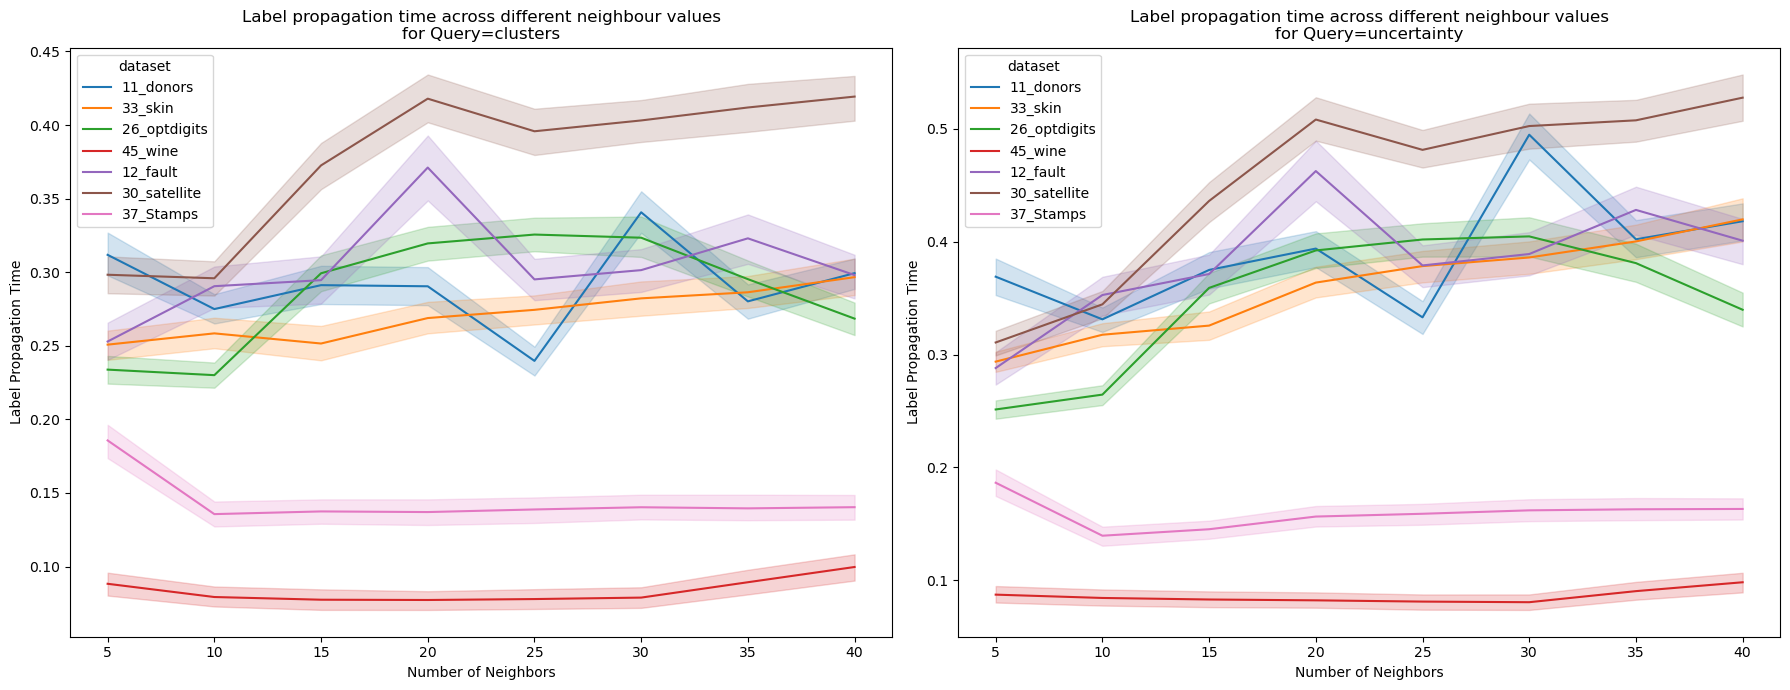

In [19]:
queries = iforest.query_strategy.unique()
fig, axes = plt.subplots(1, len(queries), figsize=(18, 7))
for i, each_query in enumerate(queries):
    each_iforest_data = iforest[iforest.query_strategy == each_query].reset_index(drop=True)
    sns.lineplot(
        x="n_neighbors",
        y="label_prop_time",
        data=each_iforest_data,
        hue="dataset",
        ax=axes[i]  
    )
    axes[i].set_title(f"Label propagation time across different neighbour values\nfor Query={each_query}")
    axes[i].set_xlabel("Number of Neighbors")
    axes[i].set_ylabel("Label Propagation Time")
plt.tight_layout()
plt.show()

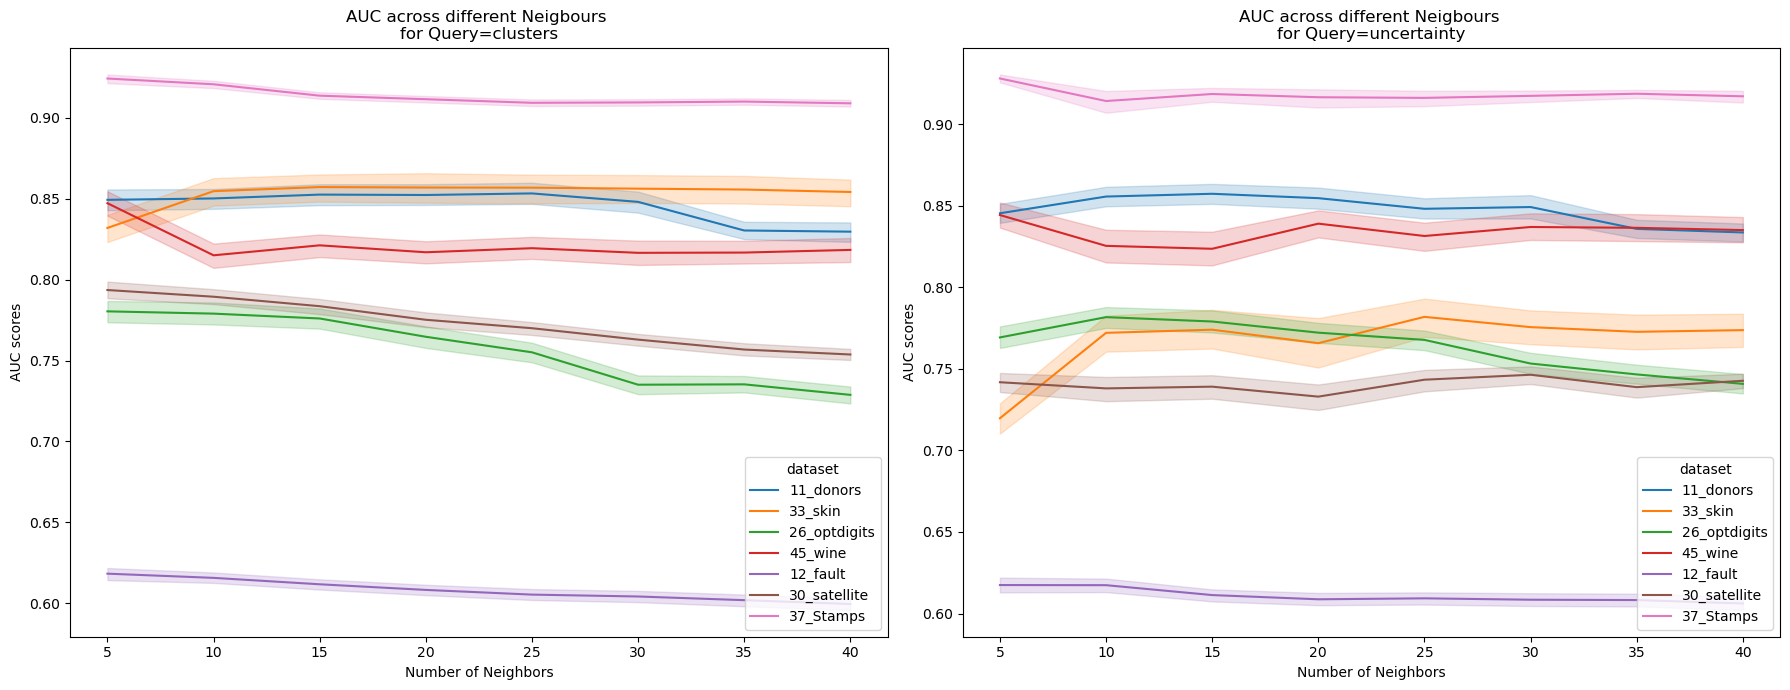

In [20]:
queries = iforest.query_strategy.unique()
fig, axes = plt.subplots(1, len(queries), figsize=(18, 7))
for i, each_query in enumerate(queries):
    each_iforest_data = iforest[iforest.query_strategy == each_query].reset_index(drop=True)
    sns.lineplot(
        x ="n_neighbors",
        y ="roc_auc",
        data= each_iforest_data,
        hue = "dataset",
        ax=axes[i]
    )
    axes[i].set_title(f"AUC across different Neigbours \nfor Query={each_query}")
    axes[i].set_xlabel("Number of Neighbors")
    axes[i].set_ylabel("AUC scores")
plt.tight_layout()
plt.show()




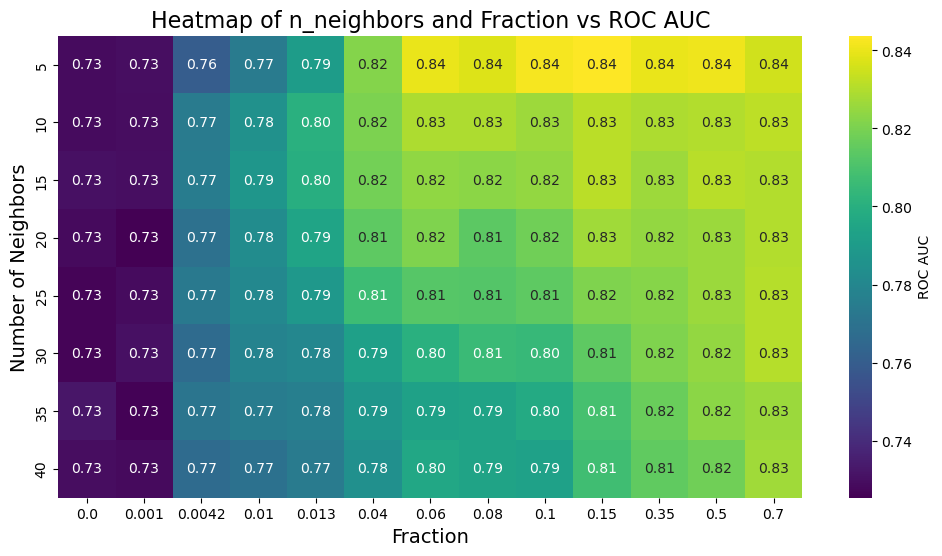

In [21]:
# as per fraction
"""
Checking for only clustering one
"""
clustering_information = iforest[iforest.query_strategy == "clusters"].reset_index(drop=True)
plt.figure(figsize=(12, 6))
pivot_roc_auc_neighbors = clustering_information.pivot_table(values='roc_auc', index='n_neighbors', columns='fraction', aggfunc='mean')
sns.heatmap(pivot_roc_auc_neighbors, cmap='viridis', annot=True, fmt=".2f", cbar_kws={'label': 'ROC AUC'})
plt.title('Heatmap of n_neighbors and Fraction vs ROC AUC', fontsize=16)
plt.xlabel('Fraction', fontsize=14)
plt.ylabel('Number of Neighbors', fontsize=14)
plt.show()

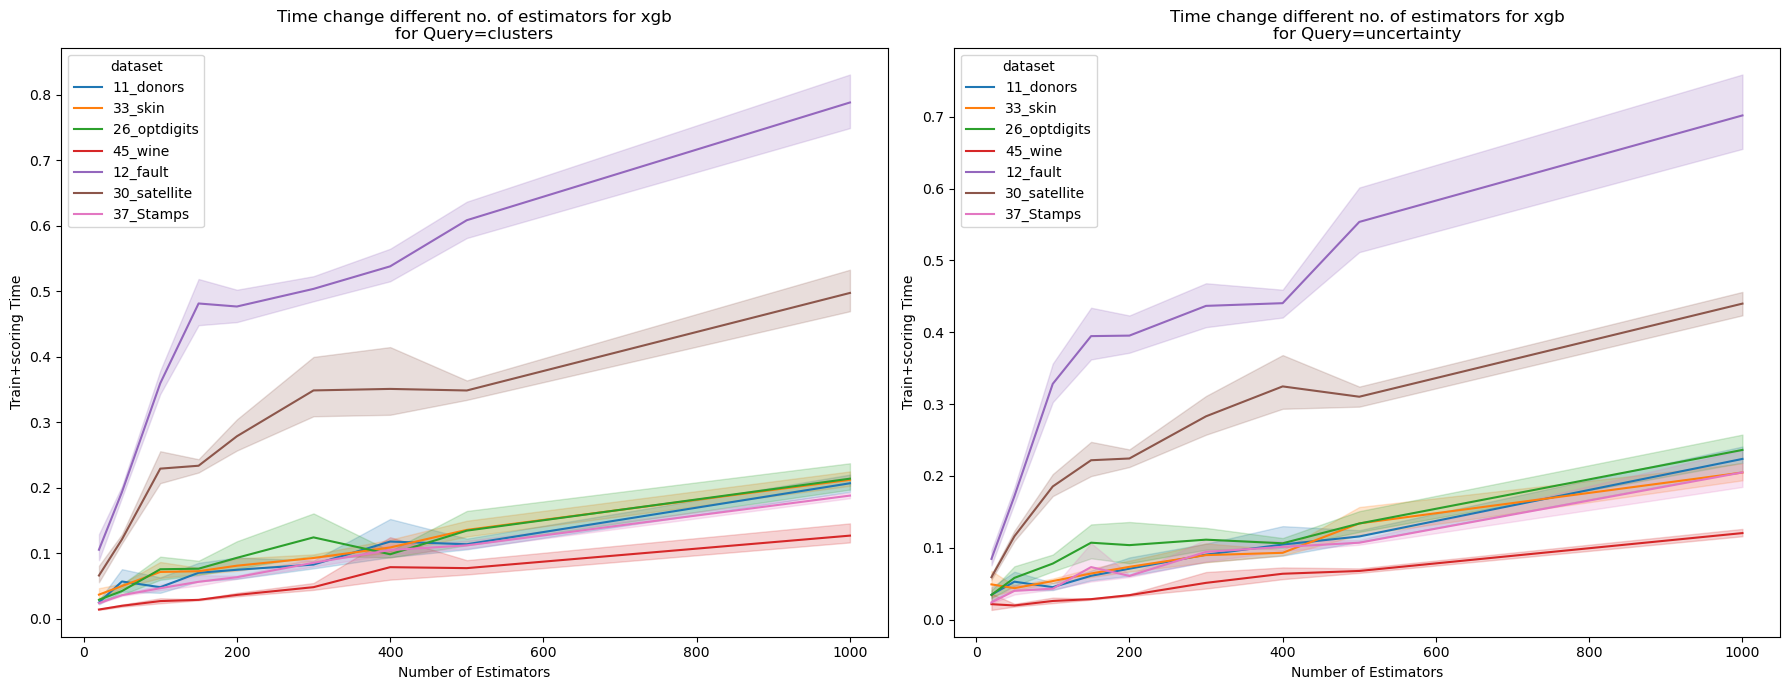

In [22]:
# for the case of gboost

queries = iforest.query_strategy.unique()
fig, axes = plt.subplots(1, len(queries), figsize=(18, 7))
for i, each_query in enumerate(queries):
    each_xgb_data = xgb[xgb.query_strategy == each_query].reset_index(drop=True)
    sns.lineplot(
        x="estimators",
        y="time",
        data=each_xgb_data,
        hue="dataset",
        ax=axes[i]  
    )
    axes[i].set_title(f"Time change different no. of estimators for xgb\nfor Query={each_query}")
    axes[i].set_xlabel("Number of Estimators")
    axes[i].set_ylabel("Train+scoring Time")
plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'AUC across different no. of estimators for xgb for Clustering')

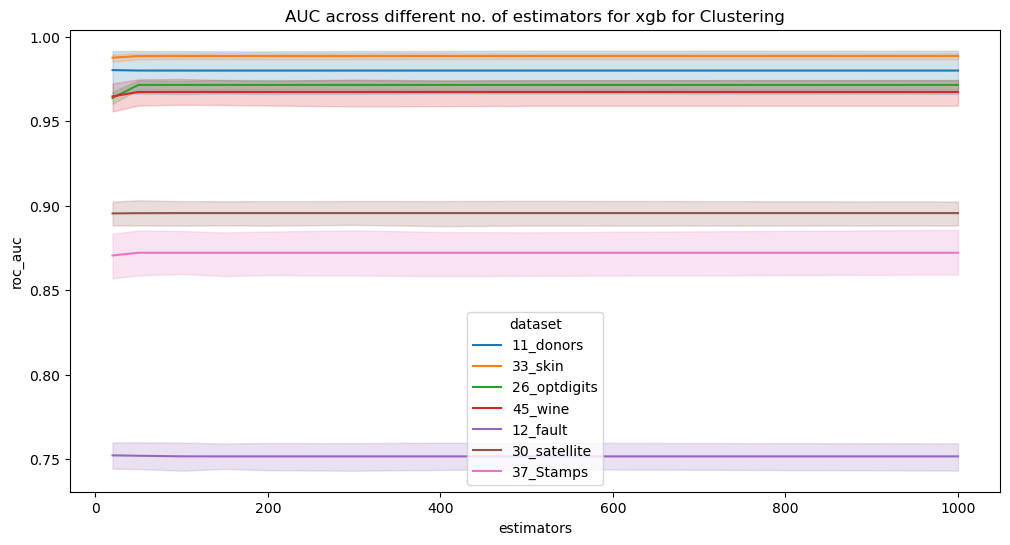

In [23]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    x ="estimators",
    y ="roc_auc",
    data= xgb[xgb.query_strategy=="clusters"],
    hue = "dataset",
)

plt.title("AUC across different no. of estimators for xgb for Clustering")




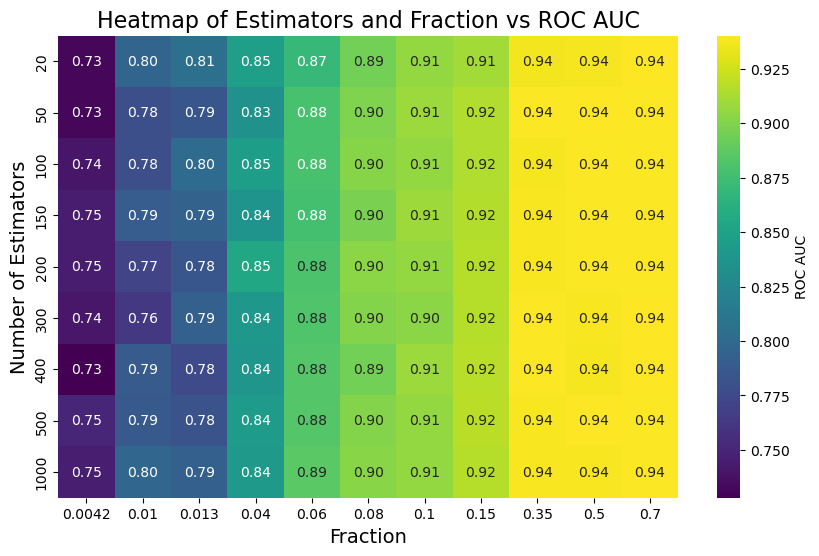

In [24]:
pivot_roc_auc_estimators = xgb.pivot_table(values='roc_auc', index='estimators', columns='fraction', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_roc_auc_estimators, cmap='viridis', annot=True, fmt=".2f", cbar_kws={'label': 'ROC AUC'})
plt.title('Heatmap of Estimators and Fraction vs ROC AUC', fontsize=16)
plt.xlabel('Fraction', fontsize=14)
plt.ylabel('Number of Estimators', fontsize=14)
plt.show()

### Effect of Sample Size on AUC/Time

In [25]:
sample_size_data =  pd.read_csv("test_by_size.csv")

In [26]:
sample_size_data.shape

(17757, 14)

In [27]:
# add some additional information
sample_size_data[['num_categorial', 'num_numerical', 'num_columns']] = sample_size_data['dataset'].map(metadata_series).apply(pd.Series)

In [28]:
# filter only iforest data
iforest_size_data = sample_size_data[sample_size_data["model"] !="XGB"].reset_index(drop=True)

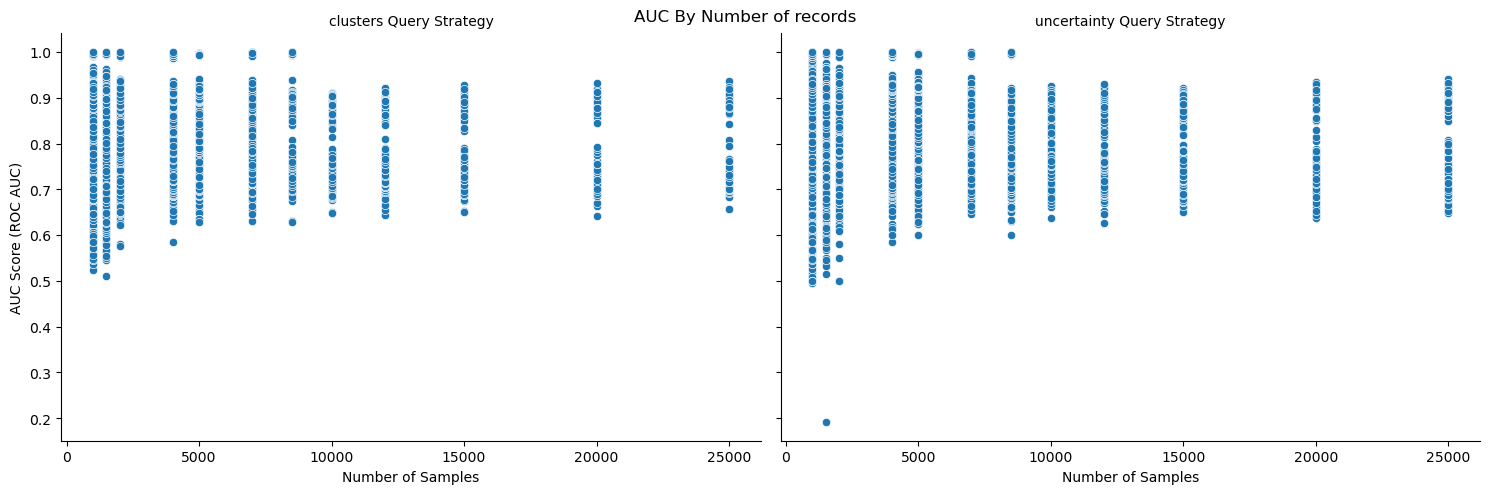

In [29]:
g = sns.FacetGrid(iforest_size_data, col='query_strategy', height=5, aspect=1.5)
g.map(sns.scatterplot, 'num_samples', 'roc_auc')
g.set_axis_labels("Number of Samples", "AUC Score (ROC AUC)")
g.set_titles("{col_name} Query Strategy")
plt.suptitle("AUC By Number of records")
plt.show()


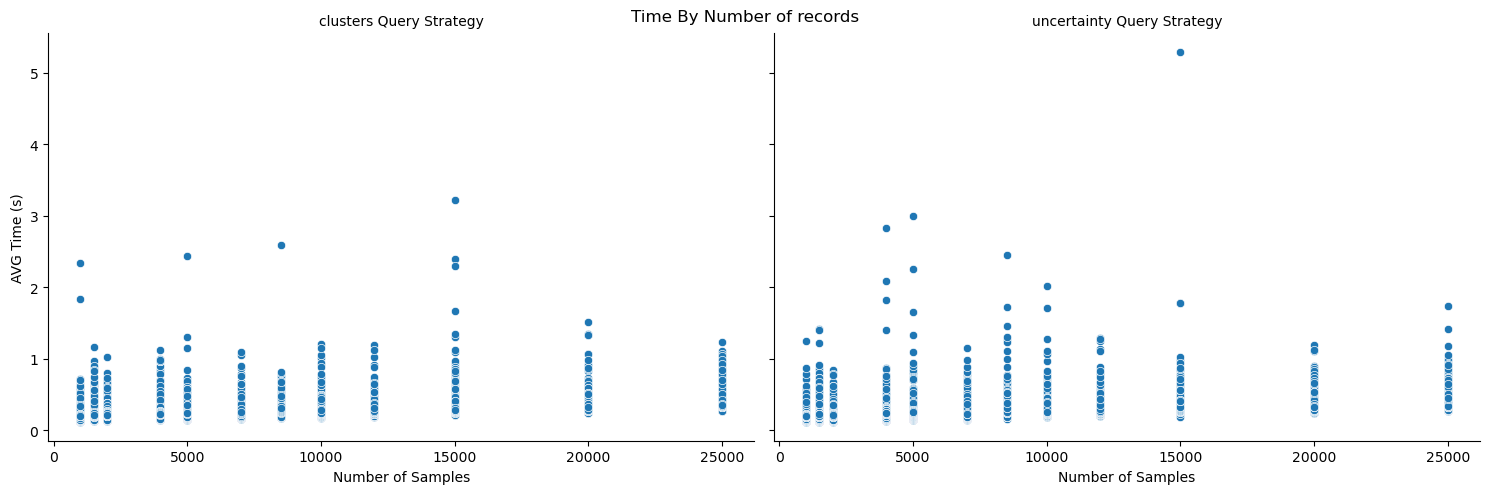

In [30]:
g = sns.FacetGrid(iforest_size_data, col='query_strategy', height=5, aspect=1.5)
g.map(sns.scatterplot, 'num_samples', 'time')
g.set_axis_labels("Number of Samples", "AVG Time (s)")
g.set_titles("{col_name} Query Strategy")
plt.suptitle("Time By Number of records")
plt.show()


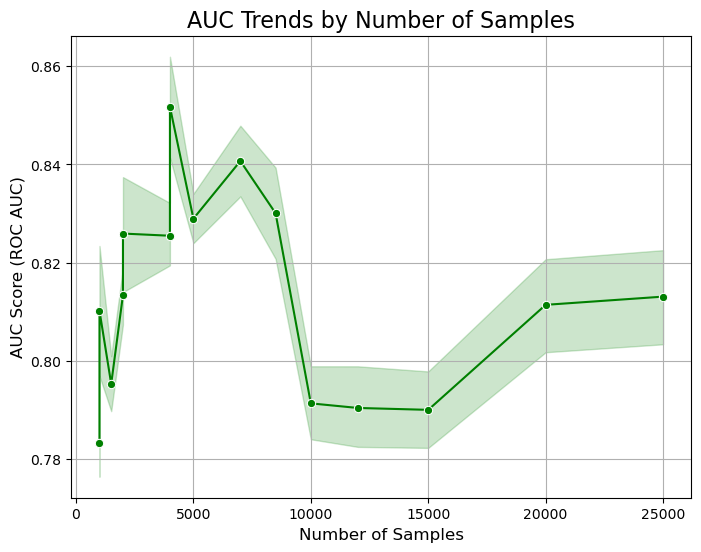

In [31]:
# average UAC 
plt.figure(figsize=(8, 6))
sns.lineplot(data=iforest_size_data, x='num_samples', y='roc_auc', marker='o', color='green')
plt.title("AUC Trends by Number of Samples", fontsize=16)
plt.xlabel("Number of Samples", fontsize=12)
plt.ylabel("AUC Score (ROC AUC)", fontsize=12)
plt.grid(True)
plt.show()


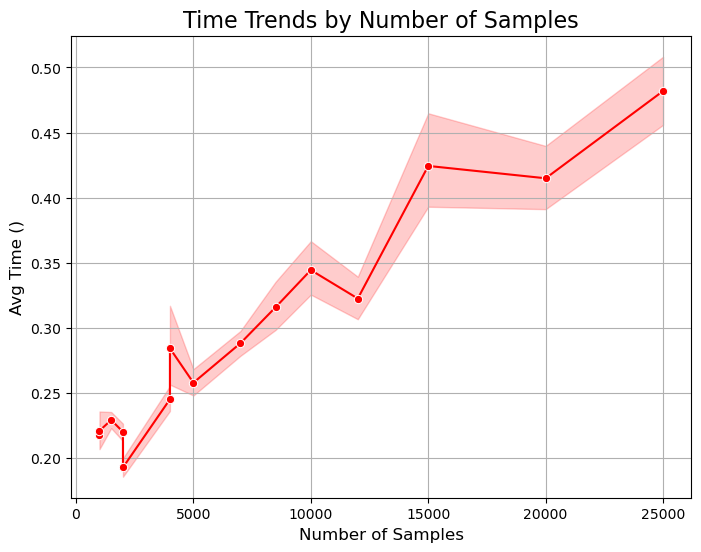

In [32]:
plt.figure(figsize=(8, 6))
sns.lineplot(data=iforest_size_data, x='num_samples', y='time', marker='o', color='red')
plt.title("Time Trends by Number of Samples", fontsize=16)
plt.xlabel("Number of Samples", fontsize=12)
plt.ylabel("Avg Time ()", fontsize=12)
plt.grid(True)
plt.show()


In [33]:
iforest_size_data.head()

,dataset,num_samples,model,fraction,rep,query_strategy,propagation,kernel,num_labels,label_prop_time,estimators,n_neighbors,roc_auc,time,num_categorial,num_numerical,num_columns
0,33_skin,1001,IForest,0.0,43,clusters,True,knn,0,0.0,100,20,0.667700,0.134338,0,3,3
1,33_skin,1001,IForest,0.0,24,clusters,True,knn,0,0.0,100,20,0.605406,0.139993,0,3,3
2,33_skin,1001,IForest,0.0,100,clusters,True,knn,0,0.0,100,20,0.691944,0.137676,0,3,3
3,33_skin,1001,IForest,0.0,2024,clusters,True,knn,0,0.0,100,20,0.670558,0.150766,0,3,3
4,33_skin,1001,IForest,0.0,43,uncertainty,True,knn,0,0.0,100,20,0.660579,0.143149,0,3,3


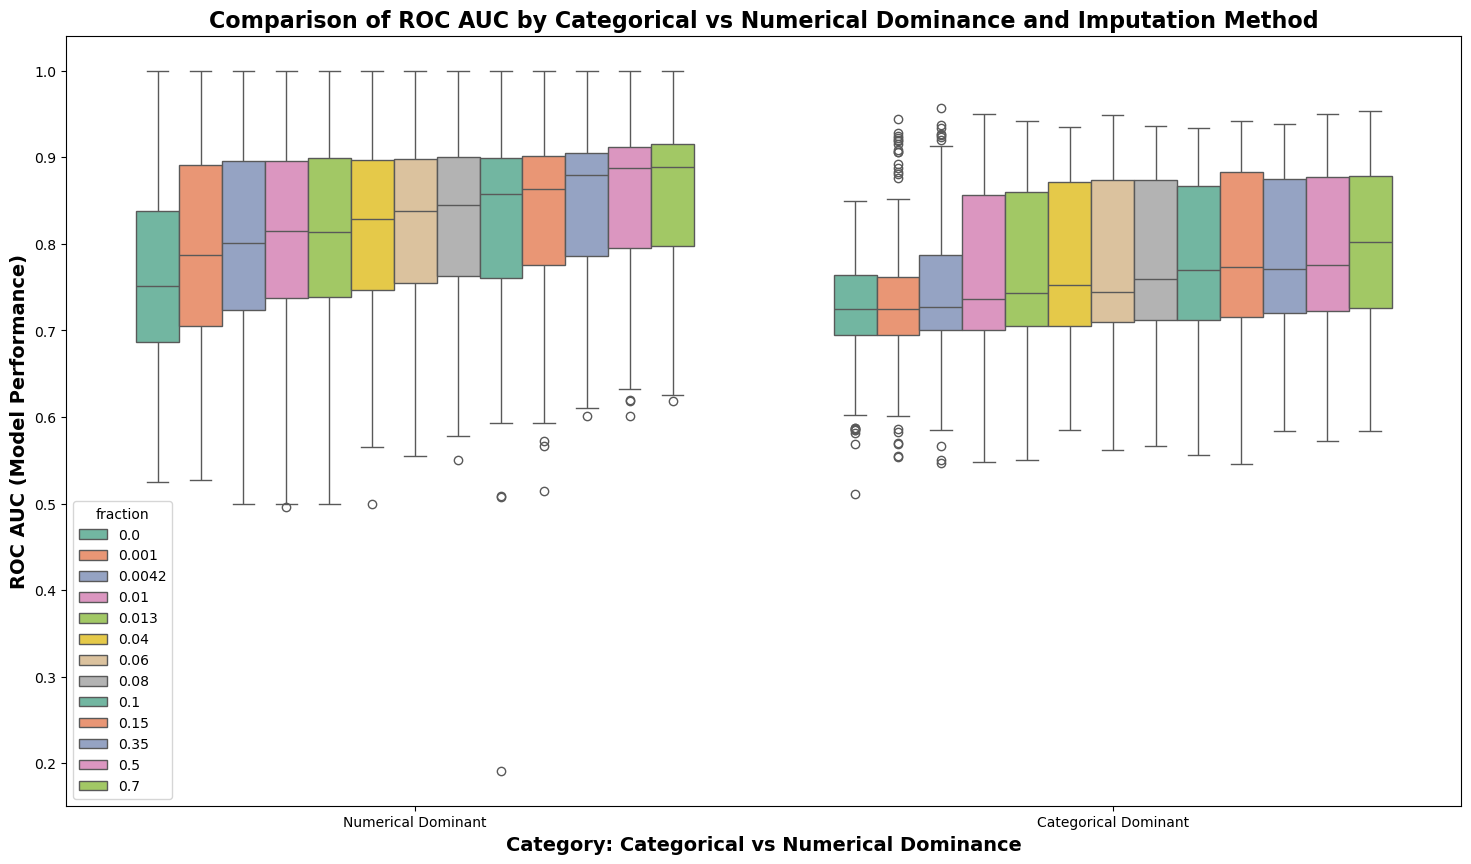

In [34]:
# plot cat vs num columns
iforest_size_data['num_cat_ratio_category'] = np.where(
    iforest_size_data['num_categorial'] >= iforest_size_data['num_numerical'], 
    'Categorical Dominant', 
    'Numerical Dominant')

plt.figure(figsize=(18, 10))
sns.boxplot(data=iforest_size_data, 
            x='num_cat_ratio_category', 
            y='roc_auc', 
            hue='fraction', 
            palette='Set2') 
plt.title('Comparison of ROC AUC by Categorical vs Numerical Dominance and Imputation Method', 
          fontweight="bold", 
          fontsize=16)

plt.xlabel('Category: Categorical vs Numerical Dominance', 
           fontweight="bold", 
           fontsize=14)

plt.ylabel('ROC AUC (Model Performance)', 
           fontweight="bold", 
           fontsize=14)
plt.show()


In [35]:
iforest_size_data.groupby(["num_cat_ratio_category", "fraction"])[["time", "roc_auc"]].mean()

time   roc_auc
num_cat_ratio_category fraction                    
Categorical Dominant   0.0000    0.289350  0.722731
                       0.0010    0.296950  0.730413
                       0.0042    0.288525  0.749013
                       0.0100    0.298214  0.767364
                       0.0130    0.291808  0.767779
                       0.0400    0.306803  0.777995
                       0.0600    0.331703  0.779631
                       0.0800    0.297673  0.784484
                       0.1000    0.293177  0.782012
                       0.1500    0.307317  0.788242
                       0.3500    0.300218  0.790071
                       0.5000    0.292063  0.793394
                       0.7000    0.297186  0.796535
Numerical Dominant     0.0000    0.272054  0.776401
                       0.0010    0.262362  0.791700
                       0.0042    0.255994  0.804064
                       0.0100    0.253013  0.816774
                       0.0130    0.257513  0.817759
                       0.0400    0.269537  0.824903
                       0.0600    0.264738  0.834567
                       0.0800    0.245349  0.837883
                       0.1000    0.258269  0.839888
                       0.1500    0.264660  0.848592
                       0.3500    0.239094  0.858356
                       0.5000    0.256955  0.863951
                       0.7000    0.257466  0.866331

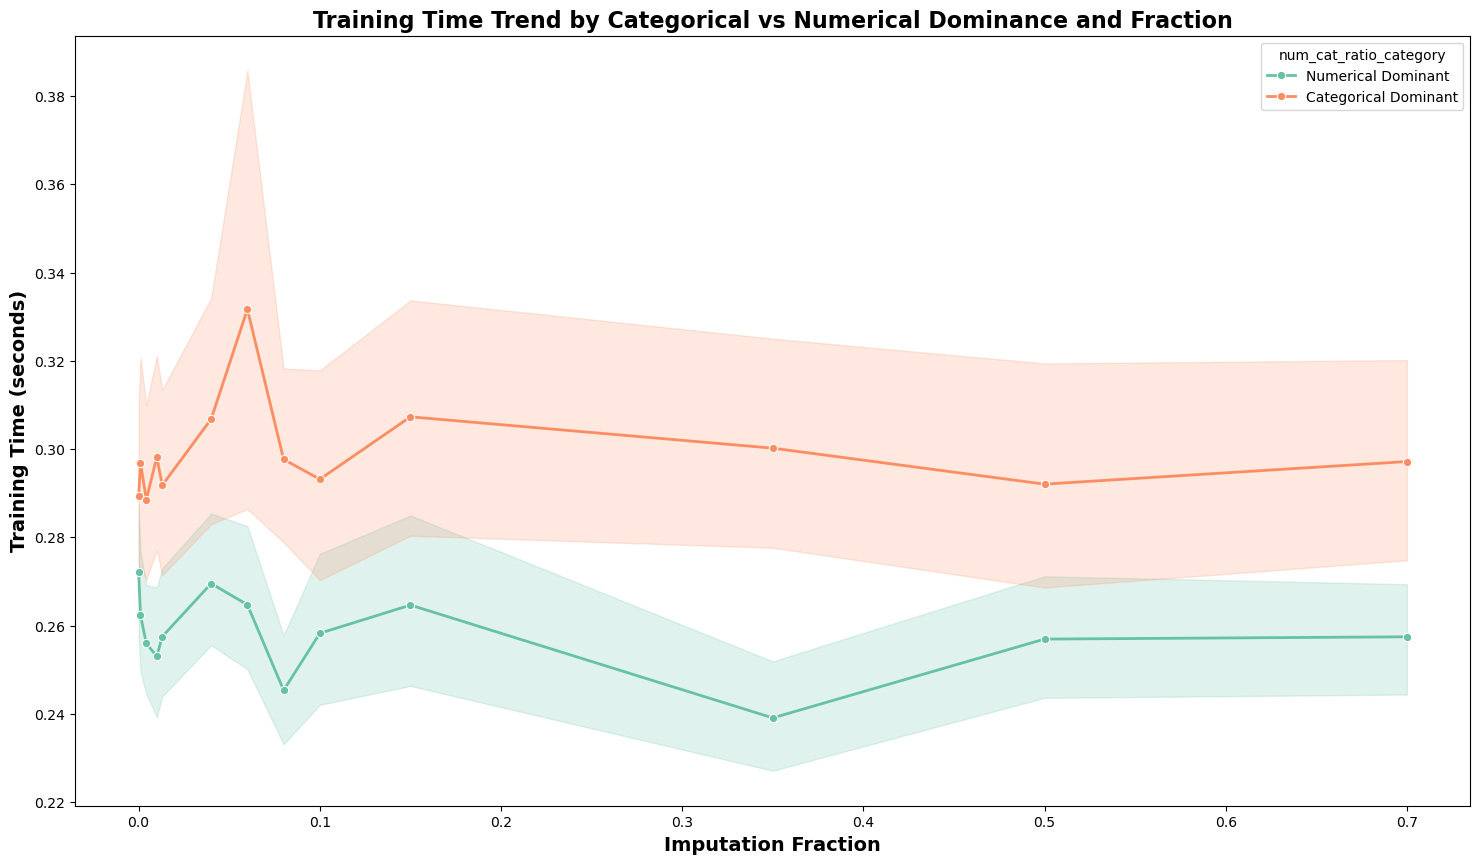

In [36]:
plt.figure(figsize=(18, 10))
# plt training time vs fraction for both categories with lines
sns.lineplot(data=iforest_size_data, 
             x='fraction', 
             y='time', 
             hue='num_cat_ratio_category', 
             palette='Set2', 
             marker='o', 
             linewidth=2)

plt.title('Training Time Trend by Categorical vs Numerical Dominance and Fraction', 
          fontweight="bold", fontsize=16)
plt.xlabel('Imputation Fraction', fontweight="bold", fontsize=14)
plt.ylabel('Training Time (seconds)', fontweight="bold", fontsize=14)
plt.show()


In [37]:
iforest_size_data.columns

Index(['dataset', 'num_samples', 'model', 'fraction', 'rep', 'query_strategy',
       'propagation', 'kernel', 'num_labels', 'label_prop_time', 'estimators',
       'n_neighbors', 'roc_auc', 'time', 'num_categorial', 'num_numerical',
       'num_columns', 'num_cat_ratio_category'],
      dtype='object')

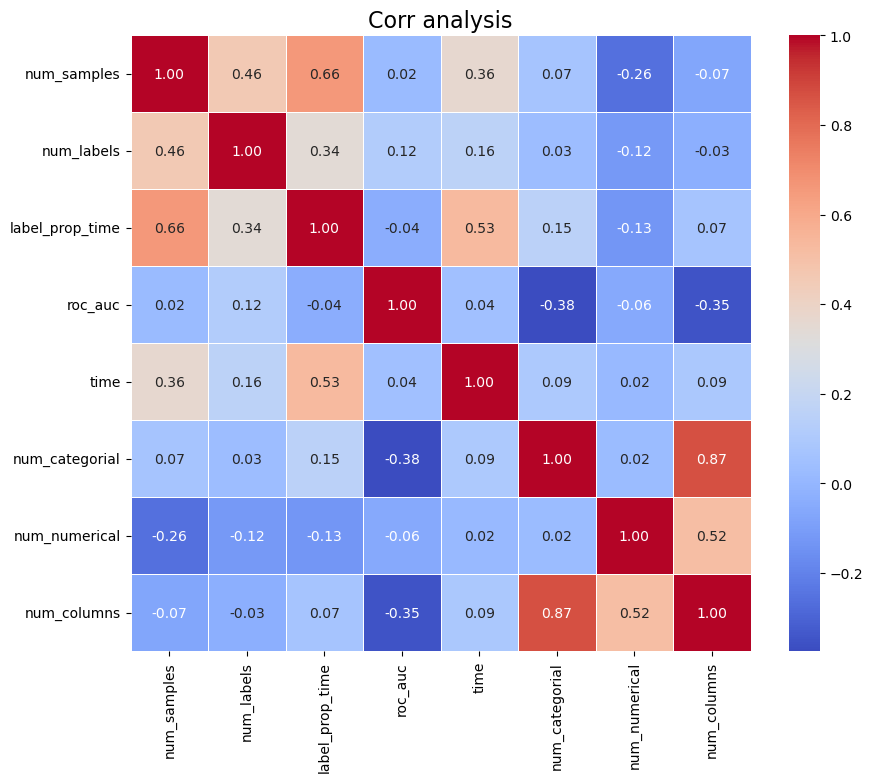

In [38]:
corr_matrix = iforest_size_data[
['num_samples','num_labels','label_prop_time', 'roc_auc','time', 'num_categorial', 'num_numerical', 'num_columns']
].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Corr analysis", fontsize=16)
plt.show()



---
### Final Summary of the Investigation:

1. **Effect of Number of Columns**:
   - **Training Time**  has a weak +ve correlation with the **number of columns** (0.087) i.e increasing number of columns, it might have a slight increase  in training time.
   - **AUC Performance**  has moderately -ve correlation with the **number of columns** (-0.350), i.e larger datasets with more columns might slightly degrade the model's performance. 
2. **Effect of Number of Categorical Features**:
   - **Training Time**  shows a very weak positive correlation with **number of categorical features** (0.092) i.e the number of categorical columns has a small effect on training time.
   - **AUC Performance** has a moderate negative correlation with **number of categorical features** (-0.376). Data with more categorical features tend to have slightly lower AUC scores (might be the issue with sparsity created by one-hot encoding)

3. **Effect of Number of Numerical Features **:
   - **Training Time**  has a weak positive correlation with **number of numerical features** (0.016) i.e it weakly affects training time and its much weaker when compaired to categorical
   - **AUC Performance**  shows a very weak negative correlation with **number of numerical features** (-0.058) i.e increasing the number of numerical features doesn't have a major impact on AUC performance.

4. **Effect of Sample Size **:
   - **Training Time** has a moderate positive correlation with **number of samples** (0.362).
   - **AUC Performance** has a very weak positive correlation with **number of samples** (0.018)
   - 

5. **Effect of Fraction **:
   - **Fraction** has little to no significant correlation with **training time** or **AUC performance**


### Summary
   - More columns lead to slightly increase in training time but might degrade AUC performance due to the added complexity.
   - A higher number of categorical features leads to lower AUC scores.
   - **Sample size** plays an important role as the training time increases with more samples, as expected.
   - The impact on AUC is weak. This might be saying that model performance is more sensitive to the nature and type of features rather than just the number of samples.
   